# Exercise 2: Classification of Airline Tweets with RNNs

This notebook implements a stacked Bidirectional LSTM with an attention mechanism for sentiment classification using the Airline Tweets dataset from Exercise 1.

In [1]:
import re
import string
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from torch.utils.data import TensorDataset, DataLoader

In [2]:
df = pd.read_csv("Tweets.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 1. Dataset Preparation

The Airline Tweets dataset from Exercise 1 is reused for this exercise.

According to the requirements, no additional exploratory data analysis is performed.  
Only the tweet text and the corresponding sentiment label are retained for the RNN classification task.

The target variable contains three sentiment classes:

- Negative
- Neutral
- Positive

In [3]:
# Keep only the columns required for sentiment classification
df = df[["text", "airline_sentiment"]].copy()

# Remove rows with missing text or sentiment values
df = df.dropna()

print("Dataset shape after selecting relevant columns:", df.shape)

df.head()

Dataset shape after selecting relevant columns: (14640, 2)


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


### Text Preprocessing

The same text cleaning procedure used in Exercise 1 is applied here in order to maintain consistency between the two exercises.

The preprocessing includes:

- Conversion of text to lowercase
- Removal of URLs
- Removal of user mentions
- Removal of the hashtag symbol while keeping the hashtag word
- Removal of punctuation
- Removal of extra whitespace

No additional feature engineering or exploratory analysis is performed.

In [4]:
def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove user mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol while keeping the word
    text = re.sub(r"#", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


### Train, Validation and Test Split

The cleaned dataset is divided into training, validation and test sets.

A stratified split is used so that the proportion of the three sentiment classes is preserved across all subsets.

The split is:

- 70% Training
- 15% Validation
- 15% Test

In [5]:
SEED = 42

X = df["clean_text"]
y = df["airline_sentiment"]


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)


print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 10248
Validation samples: 2196
Test samples: 2196


## 2. Tokenization and Vocabulary Construction

Recurrent Neural Networks cannot process raw text directly. Therefore, the cleaned tweets must first be converted into sequences of integer token IDs.

To avoid data leakage, the vocabulary is constructed using only the training set.

Two special tokens are included:

- `<PAD>` for sequence padding
- `<UNK>` for words that are not present in the training vocabulary

Words that appear only once in the training set are ignored in order to reduce vocabulary noise.

In [6]:
# Tokenize each tweet using simple whitespace splitting
train_tokens = [text.split() for text in X_train]

# Count word frequencies using only the training set
word_counts = Counter(
    word
    for tweet in train_tokens
    for word in tweet
)

# Keep words that appear at least twice
min_freq = 2

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in word_counts.items():
    if count >= min_freq:
        vocab[word] = len(vocab)


print("Vocabulary size:", len(vocab))
print("Most common words:", word_counts.most_common(10))

Vocabulary size: 5288
Most common words: [('to', 6018), ('the', 4190), ('i', 3748), ('a', 3116), ('you', 2912), ('for', 2761), ('flight', 2693), ('and', 2613), ('on', 2611), ('my', 2302)]


### Sequence Encoding

Each tweet is converted into a sequence of integer IDs based on the training vocabulary.

Words that do not exist in the vocabulary are mapped to the `<UNK>` token.

Since tweets have different lengths, the sequences will later be padded or truncated to a fixed maximum length so that they can be processed efficiently in batches.

In [7]:
def encode_text(text, vocab):
    tokens = text.split()

    return [
        vocab.get(token, vocab["<UNK>"])
        for token in tokens
    ]


X_train_encoded = [
    encode_text(text, vocab)
    for text in X_train
]

X_val_encoded = [
    encode_text(text, vocab)
    for text in X_val
]

X_test_encoded = [
    encode_text(text, vocab)
    for text in X_test
]


print("Original tweet:")
print(X_train.iloc[0])

print("\nEncoded sequence:")
print(X_train_encoded[0])

Original tweet:
suggestions tell customers approximate wait times when they are on hold 50 min now and allow them to cancelled flight online

Encoded sequence:
[2, 3, 4, 1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


### Sequence Padding

Tweets have different numbers of tokens, while neural networks typically process batches with a consistent sequence length.

For this reason, all encoded tweets are padded or truncated to a fixed maximum length.

A maximum sequence length of 50 tokens is used, which is sufficient for short-form Twitter text while keeping the model computationally efficient.

In [8]:
MAX_LEN = 50


def pad_sequence(sequence, max_len, pad_value=0):
    # Truncate long sequences
    sequence = sequence[:max_len]

    # Pad short sequences
    padding_length = max_len - len(sequence)

    return sequence + [pad_value] * padding_length


X_train_padded = [
    pad_sequence(seq, MAX_LEN)
    for seq in X_train_encoded
]

X_val_padded = [
    pad_sequence(seq, MAX_LEN)
    for seq in X_val_encoded
]

X_test_padded = [
    pad_sequence(seq, MAX_LEN)
    for seq in X_test_encoded
]


print("Sequence length:", len(X_train_padded[0]))
print("Example padded sequence:")
print(X_train_padded[0])

Sequence length: 50
Example padded sequence:
[2, 3, 4, 1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 3. Label Encoding and PyTorch DataLoaders

The sentiment labels must be converted from categorical text values into integer class IDs before they can be used for model training.

The three sentiment classes are encoded as numerical labels and then converted, together with the padded tweet sequences, into PyTorch tensors.

Finally, DataLoaders are created in order to feed the data to the neural network in mini-batches during training, validation and testing.

In [9]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", list(range(len(label_encoder.classes_))))

Classes: ['negative' 'neutral' 'positive']
Encoded classes: [0, 1, 2]


### Conversion to PyTorch Tensors

The padded tweet sequences and the encoded labels are converted into PyTorch tensors.

The tweet sequences are stored as integer tensors because they will be used as indices in the embedding layer, while the sentiment labels are stored as class IDs for the classification loss function.

In [10]:
X_train_tensor = torch.tensor(X_train_padded, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_padded, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_padded, dtype=torch.long)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

print("Training input shape:", X_train_tensor.shape)
print("Training label shape:", y_train_tensor.shape)

Training input shape: torch.Size([10248, 50])
Training label shape: torch.Size([10248])


### DataLoader Creation

PyTorch DataLoaders are used to divide the datasets into mini-batches.

A batch size of 64 is selected as a balance between computational efficiency and stable gradient updates.

The training DataLoader uses shuffling so that the model receives the training samples in a different order during each epoch. Validation and test samples are not shuffled.

In [11]:
BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 161
Validation batches: 35
Test batches: 35


In [12]:
sample_inputs, sample_labels = next(iter(train_loader))

print("Batch input shape:", sample_inputs.shape)
print("Batch label shape:", sample_labels.shape)

Batch input shape: torch.Size([64, 50])
Batch label shape: torch.Size([64])


## 4. Stacked Bidirectional LSTM with Attention

The classification model combines three RNN-based techniques suggested in the exercise:

- **Bidirectional LSTM:** processes each tweet in both forward and backward directions, allowing the model to capture contextual information from both sides of each word.
- **Stacked LSTM layers:** two recurrent layers are used to learn progressively higher-level sequential representations.
- **Attention mechanism:** the model learns which positions in each tweet are more important for sentiment classification.

The architecture consists of:

1. Embedding layer
2. Two-layer Bidirectional LSTM
3. Attention mechanism
4. Dropout regularization
5. Fully connected output layer for the three sentiment classes

In [13]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        # Bi-LSTM output size = hidden_dim * 2
        self.attention = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_output, mask):
        # lstm_output shape:
        # [batch_size, sequence_length, hidden_dim * 2]

        scores = self.attention(lstm_output).squeeze(-1)

        # Ignore padded positions
        scores = scores.masked_fill(~mask, -1e9)

        # Convert scores to attention weights
        weights = torch.softmax(scores, dim=1)

        # Weighted sum of LSTM outputs
        context = torch.sum(
            lstm_output * weights.unsqueeze(-1),
            dim=1
        )

        return context, weights

### Model Definition

The model first maps each token ID to a dense embedding vector.

The embedded sequence is then passed through a two-layer Bidirectional LSTM. Since the LSTM is bidirectional, the output representation contains information from both the forward and backward directions.

An attention layer assigns a learned importance weight to each non-padding token. The resulting context vector is passed through dropout and a fully connected layer to produce logits for the three sentiment classes.

In [14]:
class BiLSTMAttention(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        output_dim,
        num_layers=2,
        dropout=0.3
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.attention = Attention(hidden_dim)

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            hidden_dim * 2,
            output_dim
        )

    def forward(self, x):

        # Mask padded tokens
        mask = x != 0

        # Convert token IDs into dense vectors
        embedded = self.embedding(x)

        # Pass sequences through stacked Bi-LSTM
        lstm_output, _ = self.lstm(embedded)

        # Apply attention
        context, attention_weights = self.attention(
            lstm_output,
            mask
        )

        # Regularization
        context = self.dropout(context)

        # Final classification layer
        logits = self.fc(context)

        return logits, attention_weights

### Model Configuration

Moderate model dimensions are selected to provide sufficient learning capacity without making the network unnecessarily large for the relatively small Airline Tweets dataset.

The model uses:

- Embedding dimension: 128
- LSTM hidden dimension: 64
- Number of stacked LSTM layers: 2
- Bidirectional processing: enabled
- Dropout: 0.3
- Output classes: 3

In [15]:
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 64
OUTPUT_DIM = len(label_encoder.classes_)
NUM_LAYERS = 2
DROPOUT = 0.3


device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)


model = BiLSTMAttention(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

model = model.to(device)


print(model)
print("\nDevice:", device)

BiLSTMAttention(
  (embedding): Embedding(5288, 128, padding_idx=0)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=128, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

Device: mps


### Model Sanity Check

Before training, a single mini-batch is passed through the model to verify that the architecture produces outputs with the expected dimensions.

For a batch of 64 tweets and three sentiment classes, the output logits should have shape `[64, 3]`.

In [16]:
sample_inputs, sample_labels = next(iter(train_loader))

sample_inputs = sample_inputs.to(device)

with torch.no_grad():
    sample_outputs, sample_attention = model(sample_inputs)


print("Input batch shape:", sample_inputs.shape)
print("Model output shape:", sample_outputs.shape)
print("Attention weights shape:", sample_attention.shape)

Input batch shape: torch.Size([64, 50])
Model output shape: torch.Size([64, 3])
Attention weights shape: torch.Size([64, 50])


## 5. Model Training

The model is trained using Cross-Entropy Loss, which is appropriate for multi-class classification.

To address the class imbalance observed in the dataset, class weights are applied to the loss function, computed as the inverse frequency of each class in the training set. This gives proportionally more weight to the minority classes (neutral and positive) during training, encouraging the model to pay more attention to them rather than defaulting toward the majority negative class.

The Adam optimizer is used to update the model parameters.

During training, both training loss and validation loss are monitored at every epoch.

Early stopping is applied based on the validation loss in order to reduce overfitting. The model state corresponding to the lowest validation loss is preserved and restored after training.

In [17]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

NUM_EPOCHS = 20
PATIENCE = 3

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

### Training and Validation Loop

For each epoch, the model is first trained on the training set and then evaluated on the validation set.

The average loss for both subsets is stored so that learning curves can later be plotted.

Training stops early if the validation loss does not improve for three consecutive epochs.

In [18]:
for epoch in range(NUM_EPOCHS):

    # --------------------
    # Training
    # --------------------
    model.train()

    total_train_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs, _ = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()


    avg_train_loss = (
        total_train_loss / len(train_loader)
    )

    train_losses.append(avg_train_loss)


    # --------------------
    # Validation
    # --------------------
    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs, _ = model(inputs)

            loss = criterion(outputs, labels)

            total_val_loss += loss.item()


    avg_val_loss = (
        total_val_loss / len(val_loader)
    )

    val_losses.append(avg_val_loss)


    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Validation Loss: {avg_val_loss:.4f}"
    )


    # --------------------
    # Early Stopping
    # --------------------
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping activated at epoch {epoch + 1}."
        )

        break

Epoch 01 | Train Loss: 0.8676 | Validation Loss: 0.7037
Epoch 02 | Train Loss: 0.6125 | Validation Loss: 0.6596
Epoch 03 | Train Loss: 0.4926 | Validation Loss: 0.6504
Epoch 04 | Train Loss: 0.3905 | Validation Loss: 0.7271
Epoch 05 | Train Loss: 0.3025 | Validation Loss: 0.7942
Epoch 06 | Train Loss: 0.2292 | Validation Loss: 0.8409

Early stopping activated at epoch 6.


In [19]:
# Restore the model with the lowest validation loss
model.load_state_dict(best_model_state)

print(
    f"Best validation loss: {best_val_loss:.4f}"
)

Best validation loss: 0.6504


## 6. Learning Curves

The training and validation loss values are plotted across epochs in order to evaluate the learning behaviour of the model.

The training loss decreases continuously, while the validation loss reaches its minimum during the third epoch and then begins to increase.

This divergence indicates the beginning of overfitting. Early stopping prevents the model from continuing to train once validation performance stops improving, and the model state with the lowest validation loss is restored.

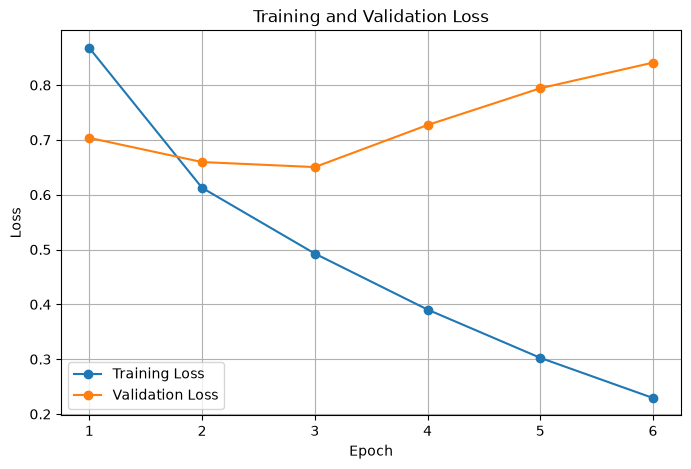

In [20]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Learning Curve Interpretation

The model learns rapidly during the first three epochs, as both training and validation loss decrease.

The minimum validation loss of approximately **0.6504** is reached at epoch 3. After this point, the training loss continues to decrease while the validation loss begins to increase.

This divergence indicates that the model starts to overfit the training data after the third epoch. Early stopping is activated at epoch 6 and the model parameters corresponding to the best validation performance are restored.

## 7. Model Evaluation

The final model is evaluated on the independent test set.

The model parameters corresponding to the lowest validation loss are used for the final evaluation.

The evaluation includes:

- Test loss
- Test accuracy
- Precision, recall and F1-score for each sentiment class
- Confusion matrix

In [21]:
model.eval()

test_loss = 0
all_predictions = []
all_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs, _ = model(inputs)

        loss = criterion(outputs, labels)
        test_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


avg_test_loss = test_loss / len(test_loader)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.6592
Test Accuracy: 0.7650


### Classification Report

The classification report provides precision, recall and F1-score for each sentiment class.

These metrics are useful because they show how well the model performs across the individual sentiment categories rather than relying only on overall accuracy.

In [22]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    negative       0.89      0.80      0.85      1377
     neutral       0.55      0.68      0.61       465
    positive       0.67      0.73      0.70       354

    accuracy                           0.77      2196
   macro avg       0.70      0.74      0.72      2196
weighted avg       0.79      0.77      0.77      2196



### Confusion Matrix

The confusion matrix provides a detailed view of the model's predictions by comparing the true sentiment labels with the predicted labels.

Correct classifications appear on the main diagonal, while off-diagonal values represent misclassifications between sentiment classes.

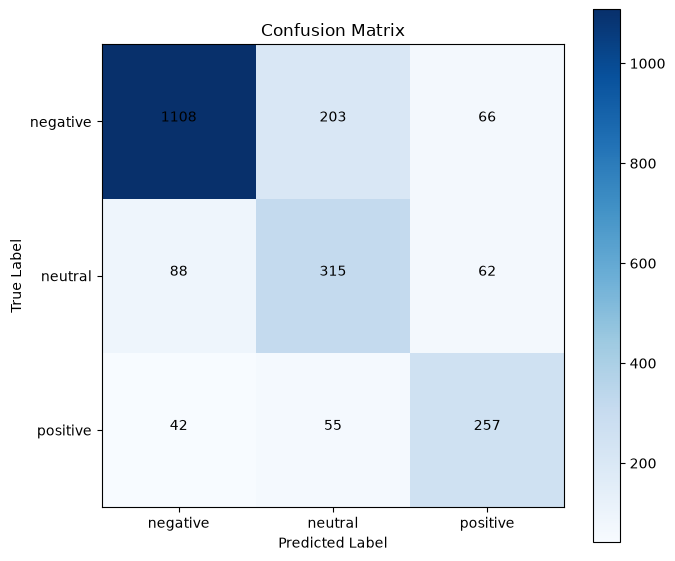

In [23]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 6))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(
    len(label_encoder.classes_)
)

plt.xticks(
    tick_marks,
    label_encoder.classes_
)

plt.yticks(
    tick_marks,
    label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            horizontalalignment="center"
        )


plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

With class weighting applied, the confusion matrix shows a shift in how errors are distributed across classes compared to the unweighted model.

Out of **1,377 negative tweets**, approximately **1,102** are classified correctly (recall 0.80) — slightly lower than without class weighting, since the model is no longer as strongly biased toward predicting negative.

For the neutral class, approximately **316 out of 465 tweets** are classified correctly (recall 0.68), a clear improvement over the unweighted model, where neutral recall was only 0.55.

For the positive class, approximately **258 out of 354 tweets** are classified correctly (recall 0.73), also improved from 0.69 without class weighting.

Overall, the model achieves approximately **76.5% test accuracy** — slightly lower than the unweighted model's 77.6%, but with meaningfully better recall on both minority classes. This reflects the expected trade-off of class weighting: a reduction in overall accuracy (driven by the dominant negative class) in exchange for more balanced performance across all three sentiment categories.

### Classification Report Interpretation

The model achieves an overall test accuracy of approximately **76.5%**, below the unweighted model's 77.6%.

Performance differs across the three sentiment classes:

- **Negative sentiment**: precision **0.89**, recall **0.80**, F1-score **0.85**. Precision remained strong, while recall decreased as the model became less biased toward this majority class.
- **Neutral sentiment**: precision **0.55**, recall **0.68**, F1-score **0.61**. Recall improved substantially (from 0.55 to 0.68), though precision dropped somewhat (from 0.62 to 0.55), as the model now predicts "neutral" more often.
- **Positive sentiment**: precision **0.67**, recall **0.73**, F1-score **0.70**. Recall improved from 0.69 to 0.73, with little change in precision.

The weighted F1-score of **0.77** matched the unweighted model's weighted F1, while the macro F1-score of **0.72** improved over the unweighted model's 0.71, confirming that class weighting produced a real improvement in balanced performance across classes, at the cost of some raw accuracy.

### Attention Weight Visualization

Since the model includes an attention mechanism, it is useful to inspect which tokens it actually focuses on when making a prediction.

Below, attention weights are visualized for a few individual test tweets, with darker shading indicating higher attention weight. This provides a qualitative check on whether the model attends to sentiment-bearing words rather than uninformative function words.

Tweet: im upset because we were lied to was told ice on runway but every other carrier was able to fly airport confirmed no ice
Predicted sentiment: negative



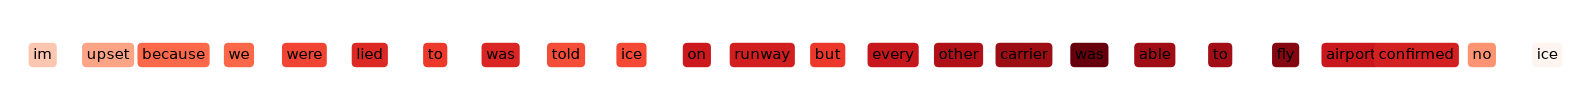

True sentiment: negative
------------------------------------------------------------
Tweet: ok pilots are looking for agents they jumped out flt 5350 dfw this is crazy
Predicted sentiment: negative



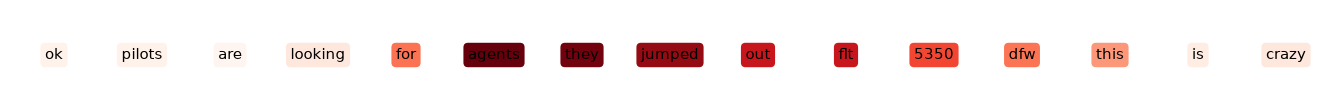

True sentiment: negative
------------------------------------------------------------
Tweet: but i take meds that make me severely dehydrated sigh
Predicted sentiment: neutral



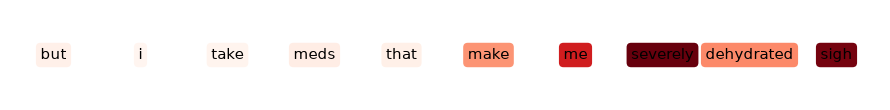

True sentiment: negative
------------------------------------------------------------


In [24]:
import matplotlib.colors as mcolors

def show_attention(text, model, vocab, label_encoder, max_len=MAX_LEN, device=device):
    model.eval()

    clean = clean_text(text)
    tokens = clean.split()
    encoded = encode_text(clean, vocab)
    padded = pad_sequence(encoded, max_len)

    input_tensor = torch.tensor([padded], dtype=torch.long).to(device)

    with torch.no_grad():
        logits, attn_weights = model(input_tensor)

    pred_class = label_encoder.classes_[torch.argmax(logits, dim=1).item()]
    weights = attn_weights[0, :len(tokens)].cpu().numpy()

    # Normalize weights for display
    norm_weights = (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)

    print(f"Tweet: {text}")
    print(f"Predicted sentiment: {pred_class}\n")

    cmap = plt.cm.Reds
    fig, ax = plt.subplots(figsize=(min(len(tokens) * 0.9, 16), 1.2))
    ax.set_xlim(0, len(tokens))
    ax.set_ylim(0, 1)
    ax.axis("off")

    for i, (tok, w) in enumerate(zip(tokens, norm_weights)):
        ax.text(
            i + 0.5, 0.5, tok,
            ha="center", va="center",
            fontsize=11,
            bbox=dict(boxstyle="round", facecolor=cmap(w), edgecolor="none")
        )

    plt.tight_layout()
    plt.show()


# Pick a few example tweets from the test set to inspect
sample_indices = [0, 1, 2]

for idx in sample_indices:
    original_text = X_test.iloc[idx]
    true_label = label_encoder.classes_[y_test_encoded[idx]]
    show_attention(original_text, model, vocab, label_encoder)
    print(f"True sentiment: {true_label}")
    print("-" * 60)

The visualizations suggest that the model often assigns higher attention weight to sentiment-bearing words rather than distributing attention uniformly across the tweet.

However, these examples provide only a qualitative illustration and should not be interpreted as a complete explanation of the model's decision-making process.

## 8. Conclusion

In this exercise, a sentiment classification model based on a stacked Bidirectional LSTM with an attention mechanism was developed for the Airline Tweets dataset.

Unlike the feed-forward neural network approach used in Exercise 1, the RNN-based model processes tweets as ordered token sequences. An embedding layer was used to learn distributed word representations, while the Bidirectional LSTM captured contextual information in both forward and backward directions.

Two stacked LSTM layers were used to increase the model's ability to learn sequential patterns, and an attention mechanism was added to allow the model to assign greater importance to the most informative parts of each tweet.

To address class imbalance, class weights (inverse class frequency) were applied to the loss function, giving proportionally more weight to the neutral and positive classes during training.

The training process showed clear signs of overfitting after the third epoch. Validation loss reached its minimum at approximately **0.6504**, while training loss continued to decrease afterwards. Early stopping was activated at epoch 6 and restored the model parameters corresponding to the best validation performance.

On the independent test set, the final model achieved approximately **76.5% accuracy**, with a **weighted F1-score of 0.77** and a **macro F1-score of 0.72**. Compared to the unweighted version of this model, class weighting produced a reduction in raw accuracy (77.6% → 76.5%) but a clear improvement in recall for the minority classes — neutral recall rose from 0.55 to 0.68 and positive recall rose from 0.69 to 0.73 — along with a slightly higher macro F1-score (0.71 → 0.72).

### Comparison with Exercise 1

This sequence-based model still performs below the revised feed-forward ANN from Exercise 1, which used TF-IDF features and achieved **80.7% accuracy** and a **macro F1-score of 0.75**.

This is not unexpected given the setup used here: the embedding layer is learned entirely from scratch on a relatively small training set (~10,000 tweets), with no pretrained word vectors. TF-IDF, by contrast, directly encodes term-frequency signal that is already strongly predictive for short, informal text like tweets. The sequential/contextual advantage that Bi-LSTMs typically offer tends to become more valuable on longer documents and with larger training sets, or when combined with pretrained embeddings (e.g., GloVe or fastText) rather than embeddings trained from random initialization.

A natural next step would be to initialize the embedding layer with pretrained vectors such as GloVe or fastText and evaluate whether this improves the RNN-based model relative to the TF-IDF baseline.

The model continues to perform best on negative sentiment, while neutral sentiment remains the most difficult class to distinguish — though class weighting narrowed this gap somewhat. Overall, the experiment demonstrates how Bidirectional LSTMs, stacked recurrent layers, attention mechanisms, and class weighting can be combined for multi-class text sentiment classification, while also illustrating that architectural sophistication alone does not guarantee better performance than a simpler, well-tuned baseline — and that handling class imbalance involves a genuine trade-off between accuracy and balanced class-wise performance.